In [14]:
import kagglehub
import os
import shutil

# Download the REFUGE2 Glaucoma dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("victorlemosml/refuge2")
print(f"Dataset downloaded to: {path}")

# Copy to /content for easy access
dataset_copy_path = "/content/refuge2"
if os.path.exists(dataset_copy_path):
    shutil.rmtree(dataset_copy_path)
shutil.copytree(path, dataset_copy_path)

print(f"Dataset copied to: {dataset_copy_path}")
print("Contents of copied directory:", os.listdir(dataset_copy_path))


100%|██████████| 1.27G/1.27G [00:16<00:00, 82.1MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/victorlemosml/refuge2/versions/1
Dataset copied to: /content/refuge2
Contents of copied directory: ['REFUGE2']


In [15]:
import kagglehub
import os
import shutil

# Download the ORIGA Glaucoma dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("sohamchakraborty2004/origa-glaucoma")
print(f"Dataset downloaded to: {path}")

# Copy to /content for easy access
dataset_copy_path = "/content/origa-glaucoma"
if os.path.exists(dataset_copy_path):
    shutil.rmtree(dataset_copy_path)
shutil.copytree(path, dataset_copy_path)

print(f"Dataset copied to: {dataset_copy_path}")
print("Contents of copied directory:", os.listdir(dataset_copy_path))


100%|██████████| 459M/459M [00:06<00:00, 70.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/sohamchakraborty2004/origa-glaucoma/versions/1
Dataset copied to: /content/origa-glaucoma
Contents of copied directory: ['ORIGA']


In [16]:
import kagglehub
import os
import shutil

# Download the HRF Dataset
print("Downloading dataset...")
path = kagglehub.dataset_download("realhaadkhan/hrf-dataset")
print(f"Dataset downloaded to: {path}")

# Copy to /content for easy access
dataset_copy_path = "/content/hrf-dataset"
if os.path.exists(dataset_copy_path):
    shutil.rmtree(dataset_copy_path)
shutil.copytree(path, dataset_copy_path)

print(f"Dataset copied to: {dataset_copy_path}")
print("Contents of copied directory:", os.listdir(dataset_copy_path))


100%|██████████| 39.1M/39.1M [00:00<00:00, 93.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/realhaadkhan/hrf-dataset/versions/1
Dataset copied to: /content/hrf-dataset
Contents of copied directory: ['HRF']


In [17]:
import os
import shutil
import random
from glob import glob

# Paths to the downloaded datasets
refuge2_path = "/content/refuge2/REFUGE2"
origa_path = "/content/origa-glaucoma/ORIGA"
hrf_path = "/content/hrf-dataset/HRF"

# Destination master dataset path
master_path = "/content/master_dataset"

# Define final structure
for split in ["train", "test"]:
    for cls in ["glaucoma", "normal"]:
        os.makedirs(os.path.join(master_path, split, cls), exist_ok=True)

# Function to collect and label images
def collect_images(base_path):
    all_images = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.png', '.jpeg', '.tif', '.bmp')):
                full_path = os.path.join(root, file)
                # infer label based on folder name
                if "glaucoma" in root.lower() or "gl" in root.lower():
                    label = "glaucoma"
                else:
                    label = "normal"
                all_images.append((full_path, label))
    return all_images

# Collect all images from three datasets
refuge_images = collect_images(refuge2_path)
origa_images = collect_images(origa_path)
hrf_images = collect_images(hrf_path)

print(f"REFUGE2: {len(refuge_images)} images")
print(f"ORIGA: {len(origa_images)} images")
print(f"HRF: {len(hrf_images)} images")

# Merge all
all_images = refuge_images + origa_images + hrf_images
random.shuffle(all_images)

# Split 80/20 for train/test
split_idx = int(0.8 * len(all_images))
train_images = all_images[:split_idx]
test_images = all_images[split_idx:]

# Helper to copy files
def copy_images(image_list, split):
    for src, label in image_list:
        dst_dir = os.path.join(master_path, split, label)
        dst = os.path.join(dst_dir, os.path.basename(src))
        shutil.copy2(src, dst)

print("Copying training images...")
copy_images(train_images, "train")

print("Copying testing images...")
copy_images(test_images, "test")

print("✅ Merge completed successfully!")
for split in ["train", "test"]:
    for cls in ["glaucoma", "normal"]:
        path = os.path.join(master_path, split, cls)
        print(f"{split}/{cls}: {len(os.listdir(path))} images")


REFUGE2: 2400 images
ORIGA: 650 images
HRF: 30 images
Copying training images...
Copying testing images...
✅ Merge completed successfully!
train/glaucoma: 519 images
train/normal: 1945 images
test/glaucoma: 146 images
test/normal: 470 images


In [18]:
import os

os.listdir("/content")

['.config',
 'master_dataset',
 'origa-glaucoma',
 'hrf-dataset',
 'refuge2',
 'sample_data']

In [19]:
os.listdir("/content")

['.config',
 'master_dataset',
 'origa-glaucoma',
 'hrf-dataset',
 'refuge2',
 'sample_data']

In [20]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

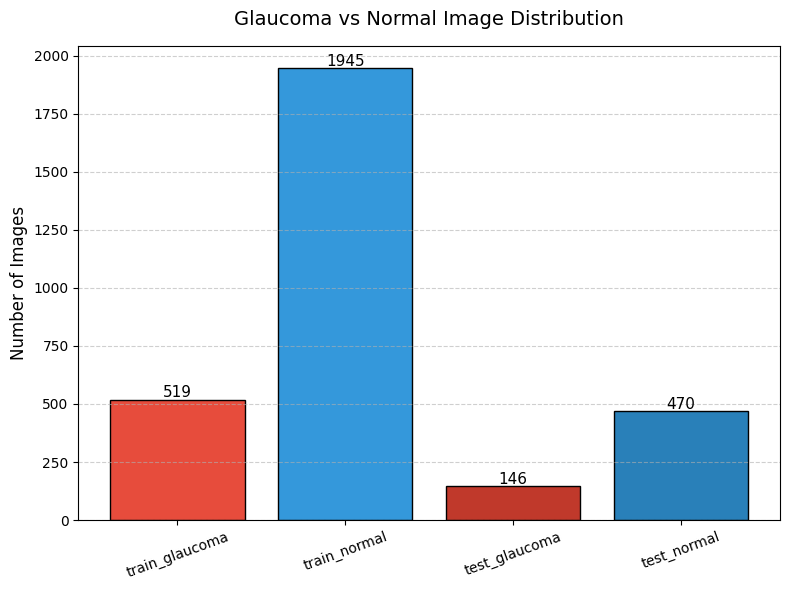

In [21]:
import matplotlib.pyplot as plt
import os

# Define paths
base_dir = "/content/master_dataset"

# Count images in each class and split
def count_images(path):
    counts = {}
    for split in ["train", "test"]:
        for cls in ["glaucoma", "normal"]:
            folder = os.path.join(path, split, cls)
            counts[f"{split}_{cls}"] = len(os.listdir(folder))
    return counts

# Get counts
counts = count_images(base_dir)

# Prepare data for plotting
splits = ["train_glaucoma", "train_normal", "test_glaucoma", "test_normal"]
values = [counts[s] for s in splits]
colors = ['#E74C3C', '#3498DB', '#C0392B', '#2980B9']  # red shades for glaucoma, blue for normal

# Plot
plt.figure(figsize=(8,6))
bars = plt.bar(splits, values, color=colors, edgecolor='black')
plt.title("Glaucoma vs Normal Image Distribution", fontsize=14, pad=15)
plt.ylabel("Number of Images", fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add counts on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10, f"{height}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()


Before Augmentation:
Glaucoma images: 519
Normal images:   1945
Images to generate: 1426

Augmentation started...

✅ Augmentation completed!

After Augmentation:
Glaucoma images: 1855
Normal images:   1945


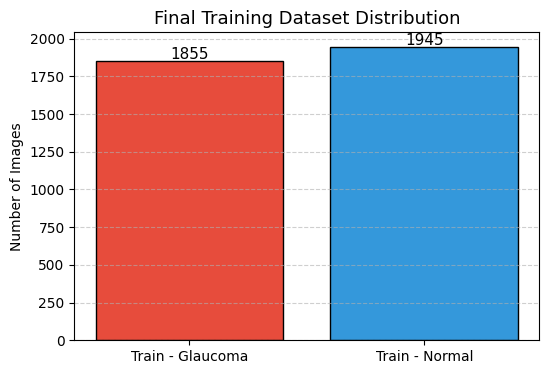

In [22]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import numpy as np
from glob import glob
import shutil
import matplotlib.pyplot as plt

# Paths
train_glaucoma_dir = "/content/master_dataset/train/glaucoma"
train_normal_dir = "/content/master_dataset/train/normal"

# Count current images
num_glaucoma = len(os.listdir(train_glaucoma_dir))
num_normal = len(os.listdir(train_normal_dir))

print(f"Before Augmentation:")
print(f"Glaucoma images: {num_glaucoma}")
print(f"Normal images:   {num_normal}")

# Difference to balance
target_count = num_normal  # we’ll make glaucoma count equal to normal
augment_needed = target_count - num_glaucoma
print(f"Images to generate: {augment_needed}")

# Create an augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Temporary folder to save augmented images
augmented_dir = os.path.join(train_glaucoma_dir, "augmented")
os.makedirs(augmented_dir, exist_ok=True)

# Load all glaucoma images
image_paths = glob(os.path.join(train_glaucoma_dir, "*.jpg")) + \
              glob(os.path.join(train_glaucoma_dir, "*.png")) + \
              glob(os.path.join(train_glaucoma_dir, "*.jpeg"))

# Augment until we reach the target count
generated = 0
img_index = 0

print("\nAugmentation started...")

while generated < augment_needed:
    img_path = image_paths[img_index % len(image_paths)]
    img = load_img(img_path)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    for batch in datagen.flow(
        x,
        batch_size=1,
        save_to_dir=augmented_dir,
        save_prefix='aug',
        save_format='jpg'
    ):
        generated += 1
        if generated >= augment_needed:
            break
    img_index += 1

print("\n✅ Augmentation completed!")

# Move augmented images into glaucoma folder
for img_file in os.listdir(augmented_dir):
    shutil.move(os.path.join(augmented_dir, img_file), os.path.join(train_glaucoma_dir, img_file))
os.rmdir(augmented_dir)

# Final counts
num_glaucoma_final = len(os.listdir(train_glaucoma_dir))
num_normal_final = len(os.listdir(train_normal_dir))

print("\nAfter Augmentation:")
print(f"Glaucoma images: {num_glaucoma_final}")
print(f"Normal images:   {num_normal_final}")

# ---- Visualization ----
plt.figure(figsize=(6,4))
plt.bar(['Train - Glaucoma', 'Train - Normal'], [num_glaucoma_final, num_normal_final],
        color=['#E74C3C','#3498DB'], edgecolor='black')
plt.title("Final Training Dataset Distribution", fontsize=13)
plt.ylabel("Number of Images")
plt.grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate([num_glaucoma_final, num_normal_final]):
    plt.text(i, v + 10, str(v), ha='center', fontsize=11)
plt.show()


In [23]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model


# Channel Attention
def channel_attention(input_feature, ratio=8):

    channel = input_feature.shape[-1]

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Dense(channel // ratio, activation='relu')(avg_pool)
    avg_pool = Dense(channel)(avg_pool)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Dense(channel // ratio, activation='relu')(max_pool)
    max_pool = Dense(channel)(max_pool)

    attention = Add()([avg_pool, max_pool])
    attention = Activation('sigmoid')(attention)
    attention = Reshape((1,1,channel))(attention)

    return Multiply()([input_feature, attention])


# Spatial Attention
def spatial_attention(input_feature):

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True),
                      output_shape=lambda s: (s[0], s[1], s[2], 1))(input_feature)

    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True),
                      output_shape=lambda s: (s[0], s[1], s[2], 1))(input_feature)

    concat = Concatenate(axis=3)([avg_pool, max_pool])

    attention = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([input_feature, attention])


# CBAM
def cbam_block(feature):

    x = channel_attention(feature)
    x = spatial_attention(x)

    return x


# Build DenseNet121
def build_densenet_cbam():

    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )

    x = base_model.output

    x = cbam_block(x)

    x = GlobalAveragePooling2D()(x)

    x = BatchNormalization()(x)

    x = Dense(256, activation='relu')(x)

    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(base_model.input, outputs)

    return model

In [24]:
model = build_densenet_cbam()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,830,948 (29.87 MB)

 Trainable params: 7,745,252 (29.55 MB)

 Non-trainable params: 85,696 (334.75 KB)

In [25]:
for root, dirs, files in os.walk("/content"):
    print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/.config/logs/2026.02.06
/content/master_dataset
/content/master_dataset/test
/content/master_dataset/test/glaucoma
/content/master_dataset/test/normal
/content/master_dataset/train
/content/master_dataset/train/glaucoma
/content/master_dataset/train/normal
/content/origa-glaucoma
/content/origa-glaucoma/ORIGA
/content/origa-glaucoma/ORIGA/Training
/content/origa-glaucoma/ORIGA/Training/glaucoma
/content/origa-glaucoma/ORIGA/Training/normal
/content/origa-glaucoma/ORIGA/Testing
/content/origa-glaucoma/ORIGA/Testing/glaucoma
/content/origa-glaucoma/ORIGA/Testing/normal
/content/hrf-dataset
/content/hrf-dataset/HRF
/content/hrf-dataset/HRF/glaucoma
/content/hrf-dataset/HRF/healthy
/content/refuge2
/content/refuge2/REFUGE2
/content/refuge2/REFUGE2/val
/content/refuge2/REFUGE2/val/images
/content/refuge2/REFUGE2/val/mask
/content/refuge2/REFUGE2/test
/content/refuge2/REFUGE2/test/images
/content/refuge2

In [27]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "/content/master_dataset/train"
test_dir = "/content/master_dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
EPOCHS = 30

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

# Evaluate
test_loss, test_acc = model.evaluate(test_data)

print("Test Accuracy:", test_acc)

Found 3040 images belonging to 2 classes.
Found 760 images belonging to 2 classes.
Found 616 images belonging to 2 classes.
Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 361s 2s/step - accuracy: 0.9908 - loss: 0.0298 - val_accuracy: 0.9750 - val_loss: 0.1298
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9977 - loss: 0.0056 - val_accuracy: 0.9829 - val_loss: 0.0551
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9618 - val_loss: 0.0991
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 1.0000 - loss: 5.0154e-04 - val_accuracy: 0.9539 - val_loss: 0.2332
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 1.0000 - loss: 6.0497e-04 - val_accuracy: 0.9500 - val_loss: 0.2373
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 1.0000 - loss: 1.4414e-04 - val_accuracy: 0.9513 - val_loss: 0.2788
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 1.0000 - loss: 1.1766e-04 - val_accurac

20/20 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step


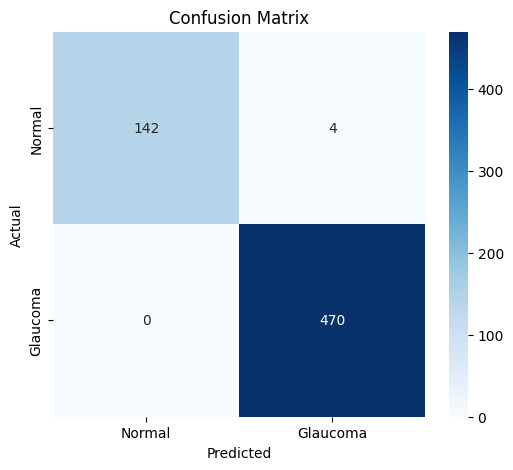


Accuracy : 0.9935064935064936
Precision: 0.9915611814345991
Recall   : 1.0
F1 Score : 0.9957627118644068

Classification Report

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99       146
    Glaucoma       0.99      1.00      1.00       470

    accuracy                           0.99       616
   macro avg       1.00      0.99      0.99       616
weighted avg       0.99      0.99      0.99       616



In [28]:
# ===============================
# Model Evaluation Metrics
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Get predictions
predictions = model.predict(test_data)

# Convert probabilities to binary
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# True labels
y_true = test_data.classes


# ===============================
# Confusion Matrix
# ===============================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Glaucoma"],
            yticklabels=["Normal","Glaucoma"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ===============================
# Metrics
# ===============================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


# ===============================
# Full Classification Report
# ===============================

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=["Normal","Glaucoma"]))

In [29]:
# ===============================
# DenseNet121 WITHOUT CBAM
# ===============================

import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model


def build_densenet121():

    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224,224,3)
    )

    x = base_model.output

    x = GlobalAveragePooling2D()(x)

    x = BatchNormalization()(x)

    x = Dense(256, activation='relu')(x)

    x = Dropout(0.5)(x)

    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=outputs)

    return model


model = build_densenet121()

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_4    │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_4… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_5    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_5… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 7,218,561 (27.54 MB)

 Non-trainable params: 85,696 (334.75 KB)

In [30]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.9803 - loss: 0.0676 - val_accuracy: 0.4882 - val_loss: 114.4492
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9872 - loss: 0.0373 - val_accuracy: 0.6487 - val_loss: 17.1343
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9954 - loss: 0.0161 - val_accuracy: 0.9474 - val_loss: 0.5928
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9984 - loss: 0.0057 - val_accuracy: 0.9724 - val_loss: 0.1726
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9961 - loss: 0.0186 - val_accuracy: 0.5368 - val_loss: 6.0927
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9984 - loss: 0.0109 - val_accuracy: 0.7079 - val_loss: 2.2590
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9908 - loss: 0.0312 - val_accuracy: 0.6539 - val_loss: 10.1301
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9947 - loss: 0.0137 - val_accuracy: 0.9632

20/20 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step


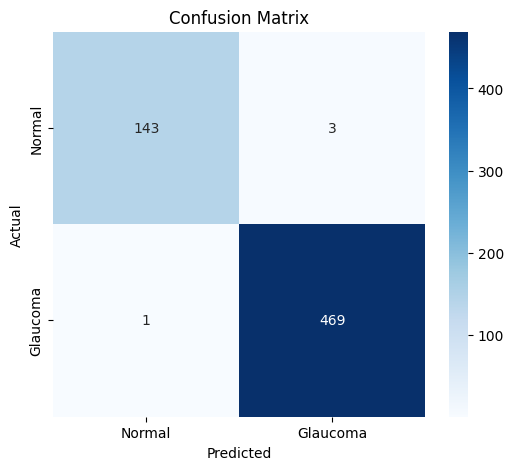


Accuracy : 0.9935064935064936
Precision: 0.9936440677966102
Recall   : 0.997872340425532
F1 Score : 0.9957537154989384

Classification Report

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99       146
    Glaucoma       0.99      1.00      1.00       470

    accuracy                           0.99       616
   macro avg       0.99      0.99      0.99       616
weighted avg       0.99      0.99      0.99       616



In [31]:
    # ===============================
# Model Evaluation Metrics
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Get predictions
predictions = model.predict(test_data)

# Convert probabilities to binary
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# True labels
y_true = test_data.classes


# ===============================
# Confusion Matrix
# ===============================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Glaucoma"],
            yticklabels=["Normal","Glaucoma"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# ===============================
# Metrics
# ===============================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nAccuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


# ===============================
# Full Classification Report
# ===============================

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=["Normal","Glaucoma"]))